# LSN-1.1 — The Five ML Jobs & the Nesting Doll

| | |
|---|---|
| **Lesson** | `LSN-1.1` — Module `MOD-1` (ML Literacy), Weeks 1–2 |
| **Serves** | `OUT-1.1` — *triage a client ask into the five ML jobs — classify, cluster, regress, propensity, recommend — and distinguish ML from generative AI* |
| **Duration** | 60 min session (15 + 25 + 20) + 30 min pre-work |
| **Verified by** | `ASM-1` — scenario quiz + live mock pre-sales conversation |
| **Homework** | **None** — `LSN-1.2`'s pre-work replaces it |
| **Lesson plan** | `program/lessons/LSN-1.1-five-ml-jobs-nesting-doll.md` |

**The skill this hour installs.** A client says *"we want to use AI for X."* Inside ten seconds you need two
answers: **is X a prediction problem at all**, and if it is, **which of five jobs**. Get it right and the rest
of discovery writes itself — you know what data to ask for, what the output looks like, and roughly what it
costs. Get it wrong and you scope a six-week model for someone who wanted a chatbot, or quote a chatbot to
someone who needed a number by Friday. That is the most expensive misunderstanding in pre-sales, and it
happens because one word — *"AI"* — covers both.

**What this notebook is.** Not a lab. The session is a discussion and a live sort; this is your **companion and
your workspace**: the pre-work you submit, the triage card you keep for the rest of the program, one small
executed example per job so each name has a picture attached, and the drill workspace with its answer key.
Every model in here is three lines of scikit-learn on synthetic data and fits in milliseconds. **Nothing here
is a modelling lesson** — `LSN-1.4` is where you train something real, and `LSN-1.2` owns the full
inputs/outputs treatment. Today is vocabulary, and vocabulary is the deliverable.

### The triage card — the one screen worth keeping

| Job | The client says… | What comes out *(one line — `LSN-1.2` does the full I/O)* | Sales-world example |
|---|---|---|---|
| **Classify** — *sort it* | "which bucket does this belong in?" | one label from a **known, fixed** list | which inbound buyers convert |
| **Cluster** — *group it* | "we don't know our categories — find them" | a group **id** per item, meaningless until a human names it | account segments |
| **Regress** — *guess a number* | "how much / how many / how long?" | one **number, with units** | next year's spend per account |
| **Propensity** — *give the odds* | "how likely is it — so we can act early?" | a **probability per entity**, built to be ranked and thresholded | odds this deal closes |
| **Recommend** — *pick the next move* | "what should we do / offer / load next?" | a **ranked short list** with relative scores | next best action per account |
| *(not ML)* **Generate / retrieve** | "answer questions, draft it, chat with our documents" | **sentences** — and no prediction target anywhere | → `MOD-2`, VSP's meeting-RAG |

### How to run this

1. Kernel: the repo `.venv` (Python 3.12). From the repo root: `.venv/bin/jupyter lab`.
2. **Run All** once, top to bottom, before the session. Every cell is safe to run unfilled — the fill-in cells
   tell you what is missing instead of raising (SI-11), so a fresh run is always clean.
3. Two cells save an artifact to `outputs/lsn-1.1/` (gitignored, stays on your machine): the **pre-work ask**
   and your **triage-drill answers**.
4. Order matters in exactly one place: fill in the drill cell **before** running the answer-key cell under it.
   The key is a reveal, not a hint.

## Setup — imports, palette, and what changed since `MOD-0`

Three rules this notebook obeys, so your screen and the projector agree:

- **Everything is seeded** (`SI-3`). Each example builds its own generator from its own pinned seed, so any
  single cell can be re-run in any order and give the same picture back. Two executions of this notebook
  produce byte-identical output.
- **Every chart uses the VSP palette**, drops its top/right spines and labels its axes.
- **The models are deliberately trivial.** `MOD-1` unlocks scikit-learn, so each job gets a real fitted model
  instead of hand-waving — but a `LogisticRegression` on 240 synthetic rows is a *prop*, there to make the
  output shape concrete. No accuracy claim in this notebook means anything; grading is `LSN-1.3`.

**The `MOD-0` callback you need in the room.** `LSN-0.4` closed on this: every one of the five jobs returns a
**probabilistic** answer — a guess with a confidence — computed by machinery whose **inference is
deterministic** once the weights are pinned and whose **training was stochastic**. Today does not revisit that.
It gives those five probabilistic answers their **names**, because the name is what you triage with.

In [1]:
# numpy (seeded generators + the synthetic feature tables behind every example)
import numpy as np
# pandas (the ranked lists and group summaries - a recommender's output IS a table)
import pandas as pd
# matplotlib (the five figures: four job outputs + the nesting doll)
import matplotlib.pyplot as plt
# matplotlib patches (the nested boxes in the nesting-doll diagram)
from matplotlib.patches import FancyBboxPatch
# scikit-learn: three trivial models, one per supervised job shape. New in MOD-1 (SI-24) -
# still nothing heavier: no transformers, no LLM libraries (MOD-2), no torch (LSN-1.4).
import sklearn
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
# stdlib textwrap (the answer key prints wrapped paragraphs, not 200-character lines)
import textwrap
# stdlib time (one sanity check that the model fits really are instant - SI-24)
import time
# stdlib json / getpass / datetime (the two artifacts this notebook saves to outputs/)
import json
import getpass
from datetime import datetime, timezone
# stdlib pathlib (locate the repo root without hardcoding a path - SI-5)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for
# --- reference lines, bar edges and annotation text (VSP navy-darkest).
VSP = {
    "navy":   "#59709c",  # navy-light      - primary series
    "green":  "#65a74e",  # green           - second series
    "yellow": "#ffe86b",  # yellow          - highlight (always with a dark edge)
    "mint":   "#97f377",  # green-lightest  - third series
    "ink":    "#2b374d",  # navy-darkest    - lines, edges, text
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found - are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())
OUT_DIR = REPO_ROOT / "outputs" / "lsn-1.1"      # gitignored via outputs/lsn-*/ (SI-4)

# --- The six answers this lesson allows, and the words people actually type for them.
# --- Used by all three fill-in cells below, so "classification", "sort it" and "classify"
# --- are the same answer (SI-18: never grade on an exact string).
JOBS = ("classify", "cluster", "regress", "propensity", "recommend", "llm")
_SYNONYMS = {
    "classify": ("classify", "classification", "classifier", "sort", "sort it", "sort-it", "label",
                 "labelling", "labeling", "categorise", "categorize", "multiclass", "multi-class"),
    "cluster": ("cluster", "clustering", "clusters", "group", "group it", "group-it", "segment",
                "segmentation", "unsupervised", "kmeans", "k-means"),
    "regress": ("regress", "regression", "regressor", "guess a number", "guess-a-number", "number",
                "forecast", "forecasting", "time series", "time-series", "predict a number", "estimate"),
    "propensity": ("propensity", "odds", "give the odds", "give-the-odds", "probability", "likelihood",
                   "risk score", "risk", "scoring", "churn score"),
    "recommend": ("recommend", "recommender", "recommendation", "recsys", "rank", "ranking",
                  "next best action", "next-best-action", "nba", "pick the next move", "top-n", "top n"),
    "llm": ("llm", "rag", "genai", "gen ai", "generative", "generative ai", "not ml", "not-ml", "chatbot",
            "chat", "gpt", "language model", "retrieval", "search", "summarise", "summarize", "mod-2"),
}


def normalize_job(text: str) -> str:
    """Map whatever the participant typed to one of JOBS, or '' if it is not recognisable.

    Longest match wins, so 'next best action' beats the bare 'action' and 'not ml' beats 'ml'.
    """
    t = " ".join(str(text).strip().lower().replace("_", " ").replace("/", " ").split())
    if not t:
        return ""
    best, best_len = "", 0
    for job, words in _SYNONYMS.items():
        for w in words:
            if (t == w or t.startswith(w + " ") or t.endswith(" " + w) or f" {w} " in f" {t} ") \
                    and len(w) > best_len:
                best, best_len = job, len(w)
    return best


print(f"numpy {np.__version__} - pandas {pd.__version__} - matplotlib {plt.matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}   <- new in MOD-1; models here stay trivial on purpose")
print(f"Repo root  : {REPO_ROOT}")
print(f"Artifacts  : {OUT_DIR.relative_to(REPO_ROOT)}/  (created on first save; gitignored)")
print("[PASS] Setup complete - palette loaded, paths resolved, six job words registered.")

numpy 2.5.1 - pandas 3.0.5 - matplotlib 3.11.1
scikit-learn 1.9.0   <- new in MOD-1; models here stay trivial on purpose
Repo root  : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
Artifacts  : outputs/lsn-1.1/  (created on first save; gitignored)
[PASS] Setup complete - palette loaded, paths resolved, six job words registered.


---

# Pre-work — do this **before** the session

*30 minutes total. Mandatory: no pre-work, no seat.*

| # | Task | Time | What to bring |
|---|---|---|---|
| 1 | Read the five-jobs material through the five-jobs section: the session deck `program/lessons/decks/LSN-1.1-five-ml-jobs.html`, plus the **triage card** at the top of this notebook | 20 min | Nothing to submit — you are quizzed cold in the drill |
| 2 | Write down **one real "AI" ask** from a project or client you have been on, plus **your guess at which job it is** | 10 min | The ask + your guess, in the cell below |

**About the source material.** The lesson plan points task 1 at Tyler's original ML literacy deck
(`PROGRAM_PLAN.md` §8). That deck is not in this repo. Same call as `LSN-0.4` made for its keywords section:
**the session deck for this lesson is the canonical version** — `program/lessons/decks/LSN-1.1-five-ml-jobs.html`
carries the two meanings of "AI", the five jobs with their tells and sales-world examples, and the nesting
doll. Read that plus the triage card above. Don't go hunting for a file.

### Picking your ask (task 2)

- **Use their words, not your translation.** *"Can't the system just tell us which of these are worth
  chasing?"* is a better artifact than *"they wanted lead scoring."* The whole skill operates on what a client
  actually says, and the tell you are listening for usually survives only in the original sentence.
- **A vague ask is a legitimate ask.** *"We want to use AI to be more efficient"* is the most common real one.
  Bring it. The correct pre-sales response to it is a question, and segment 1 shows which question.
- **Guess before you check.** Being wrong in the drill costs nothing and teaches more than being right. The
  session sorts these live — and per the lesson plan, **someone other than you** triages yours.

In [2]:
# --- Pre-work task 2. ONE real "AI" ask, in the client's own words, plus your guess.
#     Run the cell when you are done. It never crashes and it never grades you - it tells you
#     which line still needs work, then saves the ask so the session has raw material.
#
#     Weak:   "a client wanted machine learning for their sales team"
#     Strong: "VP Sales, Nov: 'can it tell us which of the 300 open deals are actually worth chasing
#              this quarter, we can only work about 40 of them'"

MY_ASK = ""      # what they actually said - quote it if you have the quote (60+ characters)

MY_GUESS = ""    # your guess, one word: classify | cluster | regress | propensity | recommend | llm

MY_TELL = ""     # the words in THEIR sentence that made you pick that job (a phrase, not a paraphrase)

# ---------------------------------------------------------------- checker (do not edit below)
MIN_ASK = 60
_ask, _tell = MY_ASK.strip(), MY_TELL.strip()
_guess = normalize_job(MY_GUESS)

_todo = []
if len(_ask) < MIN_ASK:
    _todo.append(f"MY_ASK: {MIN_ASK}+ characters, in the client's words. Who said it, roughly when, and "
                 f"what they asked for. If you are paraphrasing, you have already thrown away the tell.")
if not _guess:
    _todo.append("MY_GUESS: one of " + " | ".join(JOBS) + ".  ('classification', 'sort it', 'forecast', "
                 "'next best action', 'rag' and friends all normalise fine - a blank does not.)")
if len(_tell) < 8:
    _todo.append("MY_TELL: 8+ characters - the phrase from their sentence that decided it for you "
                 "('the odds', 'group them', 'how much', 'answer questions from'). This is the actual skill.")

# Advisory lint. Never blocks the save; these are the arguments segment 3 is made of.
_advice = []
if _tell and _ask and _tell.lower() not in _ask.lower():
    _advice.append("MY_TELL does not appear inside MY_ASK. That usually means the tell is yours, not theirs "
                   "- fine as an inference, but say so out loud when you present it.")
_vague = [w for w in ("efficient", "leverage", "transform", "ai-powered", "ai powered", "innovat",
                      "modernis", "moderniz", "smart", "automate everything") if w in _ask.lower()]
if _ask and _vague and not any(w in _ask.lower() for w in
                               ("predict", "forecast", "odds", "likel", "how many", "how much", "which",
                                "group", "segment", "rank", "recommend", "classif", "answer", "draft",
                                "summar", "chat")):
    _advice.append(f"MY_ASK reads like a goal, not a task ({', '.join(_vague)}) - there is no verb in it yet. "
                   f"That is the most common real ask in the wild and it is not your fault; the move is to "
                   f"ask 'what decision would this output drive, and who acts on it?' (LSN-1.6's question 1).")
if _guess == "llm" and _ask and not any(w in _ask.lower() for w in
                                        ("chat", "answer", "question", "write", "draft", "summar", "explain",
                                         "document", "manual", "policy", "email", "report", "conversat",
                                         "gpt", "assistant", "agent")):
    _advice.append("You called it an LLM ask, but nothing in the sentence asks for words out. Check you are "
                   "not routing to MOD-2 just because the client said the word 'AI' in 2026.")

if _todo:
    for _t in _todo:
        print(f"[TODO] {_t}")
    print("\n       Nothing is saved until those three are filled in. Ten minutes. One real ask beats"
          "\n       three invented ones - invented asks are obvious from the front of the room, because"
          "\n       real clients never phrase things this tidily.")
else:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    _path = OUT_DIR / f"prework_{getpass.getuser()}.json"
    _path.write_text(json.dumps({
        "lesson": "LSN-1.1", "serves": ["OUT-1.1"], "assessment": "ASM-1",
        "artifact": "pre-work: one real client 'AI' ask + a triage guess",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "ask": _ask, "guess": _guess, "tell": _tell,
    }, indent=2))
    print(f"[PASS] Ask on file, triaged as: {_guess.upper()}")
    print(f"[SAVED] {_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print("        Bring it to the session. Per the lesson plan, a DIFFERENT participant triages it -")
    print("        so the sentence has to stand on its own without you explaining what they meant.\n")
    if _advice:
        print("       [advisory only - your save is already done]")
        for _a in _advice:
            print(textwrap.fill(f"        - {_a}", width=104, subsequent_indent="          "))
    else:
        print("       No flags. Keep it: LSN-1.2 asks what that model would take in and kick out.")

[TODO] MY_ASK: 60+ characters, in the client's words. Who said it, roughly when, and what they asked for. If you are paraphrasing, you have already thrown away the tell.
[TODO] MY_GUESS: one of classify | cluster | regress | propensity | recommend | llm.  ('classification', 'sort it', 'forecast', 'next best action', 'rag' and friends all normalise fine - a blank does not.)
[TODO] MY_TELL: 8+ characters - the phrase from their sentence that decided it for you ('the odds', 'group them', 'how much', 'answer questions from'). This is the actual skill.

       Nothing is saved until those three are filled in. Ten minutes. One real ask beats
       three invented ones - invented asks are obvious from the front of the room, because
       real clients never phrase things this tidily.


---

# Segment 1 — "When they say AI…" *(15 min)*

## Two meanings, one word

The client's sentence contains the word *"AI"* twice a paragraph, and it is doing two completely different
jobs. Everything in this hour hangs off telling them apart:

| They mean… | It sounds like… | Where it goes |
|---|---|---|
| **"I want to KNOW x"** — predictive ML | *"tell us which / how many / how likely / what's next"* — an output you could put in a **spreadsheet column** | the five jobs · `MOD-1` |
| **"I want it to CONVERSE / write / reason"** — generative AI | *"a chatbot / draft it / summarise / explain / answer questions from our documents"* — an output made of **sentences** | `MOD-2` (LLMs, RAG, agents) |

Those two lead to different projects, different data questions, different timelines and different prices. A
prediction project asks *"where is the labelled history?"* and lives or dies on that answer (`LSN-1.6`). An
LLM project asks *"where are the documents, and who owns a wrong answer?"* and lives or dies on retrieval and
review. Neither one is harder or better. Confusing them is what makes a proposal miss by a factor of three.

### The tells — what to listen for in a client's mouth

| You hear… | The job | Why |
|---|---|---|
| "which bucket / which team / which type", "flag the ones that…" | **classify** | a fixed set of known answers |
| "segment them", "find patterns", "we don't know what the groups are" | **cluster** | the categories are the *unknown* |
| "how much / how many / how long / forecast the amount" | **regress** | the answer has **units** |
| "how likely", "the odds", "the risk that", "who is about to…" | **propensity** | the answer is a probability, per entity |
| "what should we do next", "which offer / which parts", "people who bought X" | **recommend** | the answer is a **ranked list** |
| "a chatbot", "answer questions from our manual", "draft / summarise / rewrite" | **not ML → `MOD-2`** | the answer is **sentences** |

### Three questions that settle almost every ask

1. **What comes out?** A number, a label, a group id, a ranked list — or sentences? Sentences means `MOD-2`.
   Ask them to describe one row of the output. If they cannot, you have found the real first deliverable.
2. **Is the answer written down anywhere for past cases?** If yes — a `resolved_by_team` column, a
   `closed_won` flag, three years of `delivered_late` — it is supervised: **classify / regress / propensity**.
   If no, you either have a **cluster** job or a **labelling project** nobody has priced yet.
3. **What will they DO with the output?** The action names the job better than the ask does. Put it in a
   bucket → classify. Plan against it → regress. Sort a queue and intervene at a threshold → propensity.
   Hand someone a short list → recommend.

Question 3 is the one that makes you sound senior, and it is the one clients have not thought about.

### A helper you can run on your own ask — and what it honestly is

The cell below is a **keyword lint** over the client's own sentence. It reports which tells it found, and it
refuses to answer when it finds none or finds a tie. Note what it is **not**: it is not ML. It is a dictionary
of phrases and a counter — deterministic, rule-based, auditable, and the right tool for twenty phrases.
Knowing when *not* to reach for a model is part of `OUT-1.1` too.

In [3]:
# --- A decision helper for the two-meanings call. Twenty lines, no model, no training data.
#     It is a keyword lint on the client's OWN sentence: it shows its work and it declines to
#     guess when the evidence is thin. Treat every answer as a candidate, not a verdict.

TELLS = {
    "classify": ("which team", "which bucket", "which category", "which type", "which of these",
                 "route", "routed", "flag", "tag", "categorise", "categorize", "sort", "is it a",
                 "yes/no", "yes or no", "spam", "approve or reject", "done", "complete"),
    "cluster": ("segment", "segments", "group them", "group our", "grouping", "find patterns",
                "personas", "look-alike", "lookalike", "we don't know", "we do not know",
                "meaningful groups", "cohorts", "similar customers"),
    "regress": ("how much", "how many", "how long", "how far", "forecast", "predict the amount",
                "estimate the", "dollar", "spend", "revenue", "duration", "days until",
                "percent complete", "% complete", "quantity", "volume", "price"),
    "propensity": ("how likely", "likelihood", "the odds", "odds a", "odds of", "probability",
                   "risk of", "risk that", "chance of", "chance that", "about to", "at risk",
                   "propensity", "churn", "intervene", "early warning"),
    "recommend": ("what should we", "next best", "next action", "recommend", "suggest", "which offer",
                  "which product", "which parts", "which spare", "also bought", "also viewed",
                  "top 5", "top five", "shortlist", "short list", "load on", "cross-sell", "upsell"),
    "llm": ("chatbot", "chat bot", "conversational", "assistant", "answer questions", "answer staff",
            "ask questions", "in natural language", "draft", "write us", "write our", "summarise",
            "summarize", "rewrite", "explain in", "from our documents", "from our manual", "policy manual",
            "knowledge base", "like chatgpt", "gpt", "copilot", "agent that"),
}
_MEANING = {"classify": "KNOW", "cluster": "KNOW", "regress": "KNOW",
            "propensity": "KNOW", "recommend": "KNOW", "llm": "CONVERSE"}
_DISAMBIGUATE = {
    frozenset(("classify", "propensity")): "do they act on the bucket, or on the number? "
                                           "'flag it' -> classify. 'rank the queue and intervene' -> propensity.",
    frozenset(("classify", "cluster")): "has anyone ever written the answer next to a past example? "
                                        "yes -> classify. no -> cluster (and someone has to name the groups).",
    frozenset(("regress", "propensity")): "does the number have units ($, days, seats) or is it the odds of "
                                          "an event? units -> regress. odds -> propensity.",
    frozenset(("classify", "recommend")): "one winner out of a handful of known buckets -> classify. "
                                          "a ranked short list out of thousands -> recommend.",
    frozenset(("propensity", "recommend")): "one probability per entity -> propensity. "
                                            "several options ranked for one entity -> recommend.",
    frozenset(("classify", "regress")): "a bucket or a quantity? 'done / not done' -> classify. "
                                        "'34% complete' -> regress. Make them read one row out loud.",
}


def triage_hint(ask: str, width: int = 100) -> dict:
    """Print the tells found in `ask` and a candidate job. Returns the raw hits (a dict, for reuse)."""
    text = " ".join(str(ask).lower().split())
    hits = {job: [p for p in phrases if p in text] for job, phrases in TELLS.items()}
    hits = {job: found for job, found in hits.items() if found}
    print(textwrap.fill(f'ASK: "{ask.strip()}"', width=width, subsequent_indent="     "))
    if not hits:
        print("  -> NO TELLS FOUND. This is not a failure of the ask, it is information: the sentence")
        print("     says what they want to feel, not what they want to happen. Do not propose. Ask:")
        print('     "what decision would this output drive, and who acts on it?"')
        return hits
    top = max(len(v) for v in hits.values())
    leaders = sorted(job for job, found in hits.items() if len(found) == top)
    for job in sorted(hits, key=lambda j: (-len(hits[j]), j)):
        mark = "**" if job in leaders else "  "
        print(f"  {mark} {job:<11} {_MEANING[job]:<8} <- " + ", ".join(f'"{p}"' for p in hits[job]))
    if len(leaders) == 1:
        print(f"  -> CANDIDATE: {leaders[0].upper()}  (a candidate, not an answer - confirm it by asking "
              f"what one row of\n     the output looks like and who acts on it)")
    else:
        print(f"  -> TIE: {' vs '.join(j.upper() for j in leaders)}")
        question = _DISAMBIGUATE.get(frozenset(leaders))
        if question:
            print(textwrap.fill(f"     ASK THIS: {question}", width=width, subsequent_indent="               "))
        else:
            print("     ASK THIS: describe one row of the output, and tell me who acts on it.")
    return hits


# Three asks that are not in today's drill - one per outcome the helper can have.
# 1: nothing found (the commonest real ask).  2: a clear candidate.  3: a genuine tie.
print("=" * 100)
triage_hint("We want to use AI to be more efficient and modernise how we work.")
print("=" * 100)
triage_hint("Which of our 12,000 subscribers are about to cancel, and how likely is each one?")
print("=" * 100)
triage_hint("Flag the deals with a real risk of slipping this quarter, so the manager can step in.")
print("=" * 100)

# And now yours, if the pre-work cell above is filled in.
_my = globals().get("MY_ASK", "").strip()
if len(_my) >= 60:
    triage_hint(_my)
    print(f"     your own guess was: {normalize_job(globals().get('MY_GUESS', '')).upper() or '(none)'}")
else:
    print("YOUR ASK: fill in MY_ASK in the pre-work cell above and re-run this cell to lint your own")
    print("          sentence. (The lint disagreeing with you is the interesting case, not the failure.)")
print("=" * 100)

ASK: "We want to use AI to be more efficient and modernise how we work."
  -> NO TELLS FOUND. This is not a failure of the ask, it is information: the sentence
     says what they want to feel, not what they want to happen. Do not propose. Ask:
     "what decision would this output drive, and who acts on it?"
ASK: "Which of our 12,000 subscribers are about to cancel, and how likely is each one?"
  ** propensity  KNOW     <- "how likely", "about to"
  -> CANDIDATE: PROPENSITY  (a candidate, not an answer - confirm it by asking what one row of
     the output looks like and who acts on it)
ASK: "Flag the deals with a real risk of slipping this quarter, so the manager can step in."
  ** classify    KNOW     <- "flag"
  ** propensity  KNOW     <- "risk of"
  -> TIE: CLASSIFY vs PROPENSITY
     ASK THIS: do they act on the bucket, or on the number? 'flag it' -> classify. 'rank the queue
               and intervene' -> propensity.
YOUR ASK: fill in MY_ASK in the pre-work cell above and re-r

## The nesting doll — ML ⊃ deep learning ⊃ generative AI

The second thing clients scramble, and the reason *"do you do AI or ML?"* is an unanswerable question. These
are not competing options; they are **rings inside each other**:

- **Machine learning** — the whole ring. Anything that learns its behaviour from data instead of being
  programmed rule by rule. The five jobs live here. Most of them are best solved by boringly small models.
- **Deep learning** — a *subset* of ML: neural networks with many layers, which is what you reach for when the
  input is raw and unstructured — pixels, audio, text. `LSN-1.4` trains one; `LSN-1.5` gives you the CNN / RNN
  / RL vocabulary.
- **Generative AI** — a *subset* of deep learning: models whose output is new content rather than a label or a
  number. LLMs, chatbots, RAG, image generation. This is `MOD-2`, and it is where the client's *other* meaning
  of "AI" lives.

Two things to say out loud with the picture:

1. **Inner rings are not upgrades.** Deeper is not better; it is different tooling for messier inputs. Solving
   a tabular classification problem with an LLM is usually the wrong tool at ten times the cost — and in 2026
   it is the single most common architectural mistake in the market.
2. **Not everything called "AI" is even in the outer ring.** Rule engines, RPA, an optimiser, a SQL dashboard
   with a threshold on it — all of it gets sold as AI, and some of it is the correct answer to the client's
   problem. Noticing that is worth more to a client than a model.

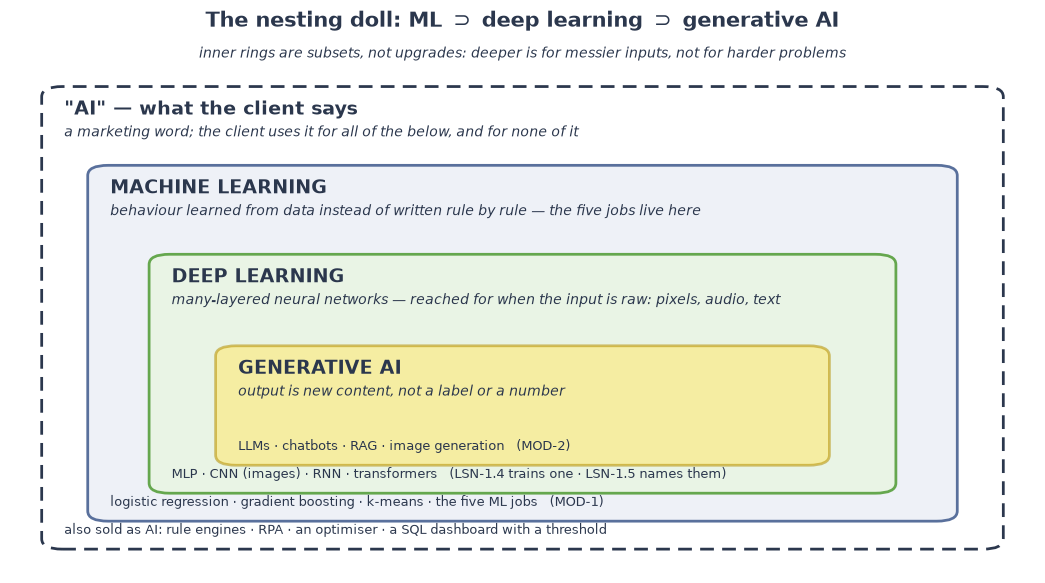

Two sentences that use this picture in a meeting:
  "Machine learning is the whole field; deep learning is the part of it that handles images and
   text; generative AI is the part of deep learning that writes things. Your ask sits here -"
  "- and that matters because it changes the data question I need to ask you next."


In [4]:
# --- The nesting doll. One figure, no data - a diagram, drawn once, in the VSP palette.
fig, ax = plt.subplots(figsize=(9.6, 5.4))

RINGS = [
    # (x, y, w, h, edge colour, face colour, title, subtitle, chips)
    (0.030, 0.045, 0.940, 0.910, VSP["ink"], "#ffffff", '"AI" — what the client says',
     "a marketing word; the client uses it for all of the below, and for none of it",
     "also sold as AI: rule engines · RPA · an optimiser · a SQL dashboard with a threshold"),
    (0.075, 0.100, 0.850, 0.700, VSP["navy"], "#eef1f7", "MACHINE LEARNING",
     "behaviour learned from data instead of written rule by rule — the five jobs live here",
     "logistic regression · gradient boosting · k-means · the five ML jobs   (MOD-1)"),
    (0.135, 0.155, 0.730, 0.470, VSP["green"], "#e9f4e5", "DEEP LEARNING",
     "many-layered neural networks — reached for when the input is raw: pixels, audio, text",
     "MLP · CNN (images) · RNN · transformers   (LSN-1.4 trains one · LSN-1.5 names them)"),
    (0.200, 0.210, 0.600, 0.235, "#b58f00", VSP["yellow"], "GENERATIVE AI",
     "output is new content, not a label or a number",
     "LLMs · chatbots · RAG · image generation   (MOD-2)"),
]

for x, y, w, h, edge, face, title, subtitle, chips in RINGS:
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0,rounding_size=0.02",
                                linewidth=1.8, edgecolor=edge, facecolor=face,
                                linestyle=(0, (5, 3)) if title.startswith('"AI"') else "solid",
                                alpha=1.0 if face != VSP["yellow"] else 0.55, zorder=1))
    ax.text(x + 0.022, y + h - 0.055, title, fontsize=12.5, fontweight="bold", color=VSP["ink"], zorder=2)
    ax.text(x + 0.022, y + h - 0.098, subtitle, fontsize=9.2, color=VSP["ink"], style="italic", zorder=2)
    ax.text(x + 0.022, y + 0.030, chips, fontsize=8.8, color=VSP["ink"], zorder=2)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("The nesting doll: ML $\\supset$ deep learning $\\supset$ generative AI",
             fontsize=13.5, fontweight="bold", pad=24)
ax.text(0.5, 1.012, "inner rings are subsets, not upgrades: deeper is for messier inputs, "
                    "not for harder problems", transform=ax.transAxes, ha="center",
        fontsize=9.4, style="italic", color=VSP["ink"])
plt.tight_layout()
plt.show()

print('Two sentences that use this picture in a meeting:')
print('  "Machine learning is the whole field; deep learning is the part of it that handles images and')
print('   text; generative AI is the part of deep learning that writes things. Your ask sits here -"')
print('  "- and that matters because it changes the data question I need to ask you next."')

## The worked example — the construction-site prospect *(instructor works this live)*

A real VSP prospect, and the one `LSN-1.6` walks end to end. The ask, in their words:

> *"We fly a drone over each site every week. Tell us from the photos whether each milestone is done."*

**Triage it out loud, using the three questions:**

| | |
|---|---|
| **What comes out?** | One answer per milestone per site visit: **done / not done**. That is a row in a spreadsheet, not a sentence — so we are on the *"I want to KNOW x"* side, and the client's "AI" means predictive ML. |
| **Is the answer written down for past cases?** | Sometimes. Site managers sign off milestones in a project system, and there are archives of photos. Whether the two can be *joined* — this photo, that milestone, that date — is the whole feasibility question, and it is a data question, not a modelling one. |
| **What will they do with it?** | Release a progress payment, or send a human to look. A **bucket** drives that. |

**The job: classification.** One label from a known, fixed list, per milestone. Not one model for "the site" —
one decision per milestone, which is a much better-scoped and much more sellable pilot.

**Now change one word.** The client says instead: *"tell us the **% complete** for each site."*

**The job: regression.** Same client, same drone, same photos — a number with units instead of a bucket, and a
different everything downstream: different labels (somebody has to have written down *34%*, and two site
managers will not agree within ten points), different grading (an average miss in percentage points, not
right/wrong — `LSN-1.3`), different way to be wrong in front of a client.

That is the point of the whole hour: **the job is set by the sentence, not by the industry, not by the data,
and not by the technology.** One word changed, and the project changed.

And because the input is photographs, this one also lands **inside the deep-learning ring** — a CNN
(`LSN-1.5`), not a logistic regression on a tidy table. The doll and the five jobs are two independent
questions: *which job* and *how deep*. You need both to scope.

In [5]:
# --- The same helper, on both variants of the construction-site ask. One word changed.
print("=" * 100)
triage_hint("We fly a drone over each site every week. Tell us from the photos whether "
            "each milestone is done.")
print("=" * 100)
triage_hint("We fly a drone over each site every week. Tell us from the photos how much "
            "of each milestone is complete, as a percent.")
print("=" * 100)
print("The lint TIES on the second one, and it is right to: their own sentence contains both")
print("'complete' (which sounds like a bucket) and 'how much ... percent' (which is a quantity).")
print("That is precisely when you stop guessing and ask question 1 - describe one row of the")
print("output. '34%' is a number, so: regression.\n")
print("Same client, same camera, same photos. The verb moved and the job moved with it:")
print('  "whether each milestone is done"  -> a bucket  -> CLASSIFY')
print('  "how much ... as a percent"       -> a number  -> REGRESS')
print()
print("Park these for LSN-1.6 (data requirements) - they are the questions that decide whether either")
print("version is buildable at all:")
for _q in ("who labelled the archive photos as 'complete', and do two site managers agree?",
           "how many past examples exist per milestone type - and how few for the rare milestones?",
           "same camera angles and seasons as the sites you want to sell this on?",
           "are workers identifiable in frame, and who owns the drone footage - client or subcontractor?"):
    print(f"  - {_q}")

ASK: "We fly a drone over each site every week. Tell us from the photos whether each milestone is
     done."
  ** classify    KNOW     <- "done"
  -> CANDIDATE: CLASSIFY  (a candidate, not an answer - confirm it by asking what one row of
     the output looks like and who acts on it)
ASK: "We fly a drone over each site every week. Tell us from the photos how much of each milestone
     is complete, as a percent."
  ** classify    KNOW     <- "complete"
  ** regress     KNOW     <- "how much"
  -> TIE: CLASSIFY vs REGRESS
     ASK THIS: a bucket or a quantity? 'done / not done' -> classify. '34% complete' -> regress.
               Make them read one row out loud.
The lint TIES on the second one, and it is right to: their own sentence contains both
'complete' (which sounds like a bucket) and 'how much ... percent' (which is a quantity).
That is precisely when you stop guessing and ask question 1 - describe one row of the
output. '34%' is a number, so: regression.

Same client, same cam

---

# Segment 2 — The five jobs *(25 min)*

Five jobs, five one-line definitions, five sales-world examples, and one small executed picture each so the
name has a shape attached. Read each figure for **what comes out**, not for how good it is — every model below
is fitted on synthetic data in a few milliseconds and none of their numbers mean anything. `LSN-1.2` does the
full inputs/outputs treatment, `LSN-1.3` grades them, `LSN-1.4` trains a real one.

The order is deliberate: the two jobs that look identical (**classify** and **propensity**) are separated by
the two that are obviously different, and the boundary cases are collected at the end of the segment.

## 1 · Classify — *sort it*

| | |
|---|---|
| **In → out** | one item's features → **one label from a known, fixed list** (plus a probability per label, which `LSN-1.2` reads) |
| **Needs** | past examples where somebody already wrote the answer down |
| **Tells** | "which team / which bucket / which type", "flag the ones that…", "route it", "is this an X or a Y" |
| **Sales-world example** | **buyer conversion**: sort inbound buyers into *converts / doesn't*, so reps work the right list |

The cheapest ML project in the world is a classification project where the labels already exist as a
by-product of somebody doing their job — the team that resolved a ticket, the deal that was marked
`closed_won`, the invoice someone approved. Ask for that column early; it decides the price.

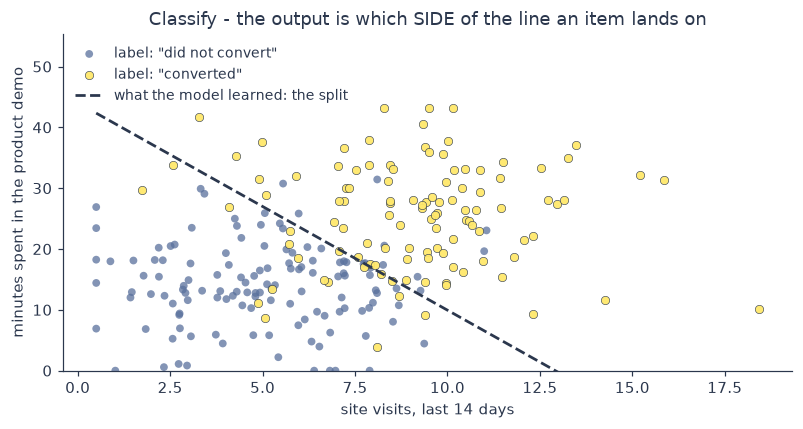

one new buyer (8 visits, 21 demo minutes) -> label: CONVERTS
                                          -> the probability behind it: 0.70   <- LSN-1.2 reads this number
[PASS] fit finished in well under a second (240 rows, 2 features)

Note what the label costs: nothing. Somebody in sales already marked these deals won or lost.
That by-product column is the difference between a 6-week project and a labelling programme.


In [6]:
# --- CLASSIFY: sort inbound buyers into converts / doesn't. Two features, one fitted line.
rng = np.random.default_rng(11)
N = 240
converted = rng.random(N) < 0.42                                    # the label, known for past buyers
visits = np.where(converted, rng.normal(9.0, 2.6, N), rng.normal(5.2, 2.4, N)).clip(0.5, None)
demo_min = np.where(converted, rng.normal(26.0, 8.0, N), rng.normal(14.0, 7.0, N)).clip(0.0, None)
X, y = np.column_stack([visits, demo_min]), converted.astype(int)

_t0 = time.perf_counter()
clf = LogisticRegression().fit(X, y)                                # 3 lines of sklearn; that is the point
_fit_s = time.perf_counter() - _t0

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.scatter(visits[~converted], demo_min[~converted], s=26, color=VSP["navy"], alpha=0.75,
           edgecolor="none", label='label: "did not convert"')
ax.scatter(visits[converted], demo_min[converted], s=30, color=VSP["yellow"], alpha=0.95,
           edgecolor=VSP["ink"], linewidth=0.4, label='label: "converted"')
w, b = clf.coef_[0], clf.intercept_[0]
xs = np.linspace(visits.min(), visits.max(), 100)
ax.plot(xs, -(w[0] * xs + b) / w[1], color=VSP["ink"], linewidth=1.8, linestyle="--",
        label="what the model learned: the split")
ax.set_xlabel("site visits, last 14 days")
ax.set_ylabel("minutes spent in the product demo")
ax.set_title("Classify - the output is which SIDE of the line an item lands on")
ax.set_ylim(0, demo_min.max() * 1.28)          # headroom so the legend never sits on a data point
ax.legend(loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

new_buyer = np.array([[8.0, 21.0]])
print(f"one new buyer (8 visits, 21 demo minutes) -> label: "
      f"{'CONVERTS' if clf.predict(new_buyer)[0] == 1 else 'DOES NOT CONVERT'}")
print(f"                                          -> the probability behind it: "
      f"{clf.predict_proba(new_buyer)[0, 1]:.2f}   <- LSN-1.2 reads this number")
print(f"[PASS] fit finished in {'well under a second' if _fit_s < 1 else f'{_fit_s:.1f} s - unexpected'}"
      f" (240 rows, 2 features)")
print("\nNote what the label costs: nothing. Somebody in sales already marked these deals won or lost.")
print("That by-product column is the difference between a 6-week project and a labelling programme.")

## 2 · Cluster — *group it*

| | |
|---|---|
| **In → out** | items' features, **no answer column** → a **group id** per item (0, 1, 2 …) |
| **Needs** | nothing labelled — which is why it is the job clients reach for first, and why it disappoints them |
| **Tells** | "segment them", "find patterns", "meaningful groups", "we don't know what our categories are" |
| **Sales-world example** | **account segments**: group accounts so marketing can treat each group differently |

The trap: the model returns `0`, `1`, `2`. Those ids mean **nothing** until a human looks at each group and
names it, and the naming is the actual deliverable — *"land-and-expand mid-market"*, *"one-off buyers"*. So the
honest scope is never "a clustering model"; it is **"three to six groups, named, and a check that they differ
on something you would act on."** And the way clients judge it is not a metric: it is whether the head of
marketing recognises their own customers in the groups.

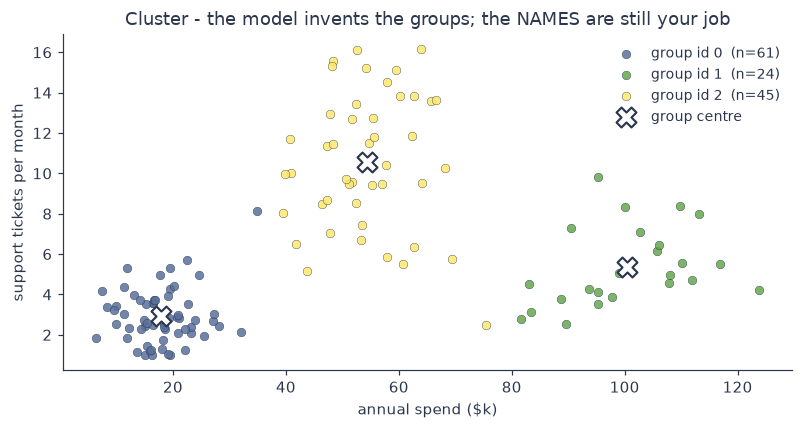

,accounts,mean spend ($k),mean tickets/mo,the name marketing needs
group id 0,61,17.9,2.9,<- you write this
group id 1,24,100.4,5.4,<- you write this
group id 2,45,54.3,10.5,<- you write this


The model's entire output is that first column of ids. Everything a client can USE is in the last
column, and no model produces it. That is why 'we'll cluster your customers' is not a deliverable.


In [7]:
# --- CLUSTER: group accounts with no labels at all. K-Means, k=3, seeded.
rng = np.random.default_rng(23)
# Three genuinely different account shapes exist in the world - but NOBODY wrote them down anywhere.
shape_a = np.column_stack([rng.normal(18, 5, 60), rng.normal(3, 1.2, 60)])     # small, quiet
shape_b = np.column_stack([rng.normal(52, 9, 45), rng.normal(11, 3.0, 45)])    # mid, chatty
shape_c = np.column_stack([rng.normal(96, 14, 25), rng.normal(5, 2.0, 25)])    # big, self-serve
accounts = np.vstack([shape_a, shape_b, shape_c]).clip(1, None)
rng.shuffle(accounts)                                                          # the model gets no order clue

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(accounts)              # no y anywhere in this line
gid = km.labels_

fig, ax = plt.subplots(figsize=(7.4, 4.0))
for k, colour in enumerate([VSP["navy"], VSP["green"], VSP["yellow"]]):
    ax.scatter(accounts[gid == k, 0], accounts[gid == k, 1], s=32, color=colour, alpha=0.85,
               edgecolor=VSP["ink"], linewidth=0.3, label=f"group id {k}  (n={int((gid == k).sum())})")
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker="X", s=170,
           color="white", edgecolor=VSP["ink"], linewidth=1.4, zorder=4, label="group centre")
ax.set_xlabel("annual spend ($k)")
ax.set_ylabel("support tickets per month")
ax.set_title("Cluster - the model invents the groups; the NAMES are still your job")
ax.legend(loc="upper right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "accounts": [int((gid == k).sum()) for k in range(3)],
    "mean spend ($k)": [accounts[gid == k, 0].mean().round(1) for k in range(3)],
    "mean tickets/mo": [accounts[gid == k, 1].mean().round(1) for k in range(3)],
    "the name marketing needs": ["<- you write this", "<- you write this", "<- you write this"],
}, index=[f"group id {k}" for k in range(3)])
display(summary)
print("The model's entire output is that first column of ids. Everything a client can USE is in the last")
print("column, and no model produces it. That is why 'we'll cluster your customers' is not a deliverable.")

## 3 · Regress — *guess a number*

| | |
|---|---|
| **In → out** | features → **one number, with units** (dollars, days, seats, degrees) |
| **Needs** | past examples with the true number recorded |
| **Tells** | "how much", "how many", "how long", "forecast the amount", "estimate the value" |
| **Sales-world example** | **spend / deal size**: how many dollars will this account spend next year |

Two things to say every time you hand over a regression number. First, **the units** — a number without units
is not an answer (`LSN-1.2` has a client asking what "8.2" means). Second, **the typical miss**: a forecast
with no error bar is a wish, and the client will plan against your decimal places if you let them. `LSN-1.3`
names that miss (MAE) and puts it in the client's own units.

A forecast — *"next quarter's spend from usage history"* — is regression with time in the features. Same job.

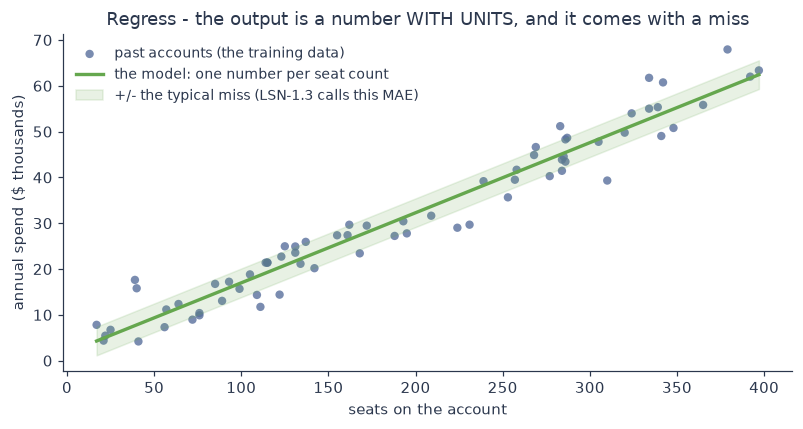

an account with  60 seats -> predicted annual spend $10,868   (typical miss: +/- $3,131)
an account with 250 seats -> predicted annual spend $39,936   (typical miss: +/- $3,131)

Say both halves out loud, always: the number AND the miss. "$39,936" invites a client
to plan to the dollar; "$39,936, typically within $3,131" is a forecast they can budget against.


In [8]:
# --- REGRESS: predict annual account spend from seat count. One feature, one fitted line.
rng = np.random.default_rng(37)
seats = rng.integers(15, 400, 70)
spend = 145.0 * seats + 3_800 + rng.normal(0, 4_200, 70)            # true relationship + real-world noise

reg = LinearRegression().fit(seats.reshape(-1, 1), spend)
grid = np.linspace(seats.min(), seats.max(), 100)
pred = reg.predict(grid.reshape(-1, 1))
typical_miss = np.abs(spend - reg.predict(seats.reshape(-1, 1))).mean()

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.scatter(seats, spend / 1_000, s=30, color=VSP["navy"], alpha=0.8, edgecolor="none",
           label="past accounts (the training data)")
ax.plot(grid, pred / 1_000, color=VSP["green"], linewidth=2.2, label="the model: one number per seat count")
ax.fill_between(grid, (pred - typical_miss) / 1_000, (pred + typical_miss) / 1_000,
                color=VSP["green"], alpha=0.15, label="+/- the typical miss (LSN-1.3 calls this MAE)")
ax.set_xlabel("seats on the account")
ax.set_ylabel("annual spend ($ thousands)")
ax.set_title("Regress - the output is a number WITH UNITS, and it comes with a miss")
ax.legend(loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

_said = {}
for s in (60, 250):
    _said[s] = reg.predict([[s]])[0]
    print(f"an account with {s:>3} seats -> predicted annual spend ${_said[s]:,.0f}"
          f"   (typical miss: +/- ${typical_miss:,.0f})")
print(f"\nSay both halves out loud, always: the number AND the miss. \"${_said[250]:,.0f}\" invites a client")
print(f"to plan to the dollar; \"${_said[250]:,.0f}, typically within ${typical_miss:,.0f}\" is a forecast "
      f"they can budget against.")

## 4 · Propensity — *give the odds*

| | |
|---|---|
| **In → out** | one entity's features → **a probability, 0 to 1**, for that entity |
| **Needs** | past examples where the event either happened or didn't — and enough of the rare side |
| **Tells** | "how likely", "the odds", "the risk that", "who is about to…", "so we can intervene early" |
| **Sales-world example** | **close odds**: the probability this open deal closes this quarter |

Mechanically this is often the *same model* as classify. What changes is the deliverable: the client acts on
**the number**, not on a bucket. That means the number has to be honest — `LSN-0.4`'s calibration lesson,
cashed: *of the deals it calls 0.70, about 70 in 100 should close.* If it isn't, the ranking may still be
useful while every conversation about it is a lie.

And the reason clients want odds rather than labels is almost always **capacity**: they can work 40 deals, call
20 depots, visit 15 sites. A probability is what you sort a limited day by, and the threshold is a business
decision — *"above 0.4, phone the depot"* — not a modelling one.

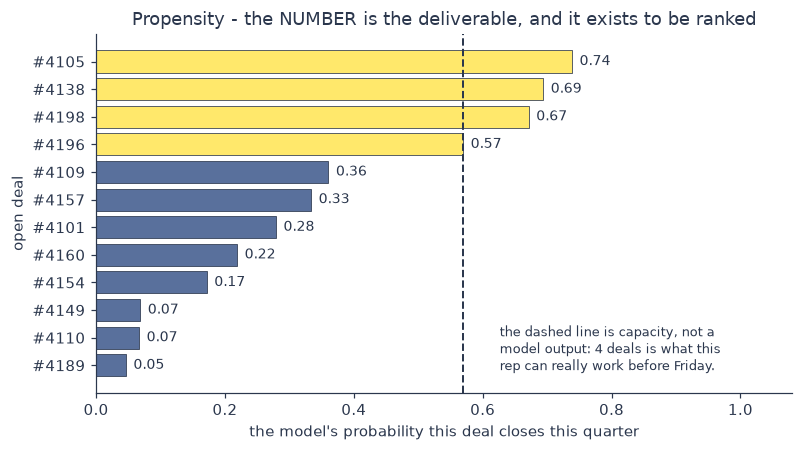

Two sentences the client needs alongside this chart, both straight out of LSN-0.4:
  1. "#4105 at 0.74 is not a promise about #4105. Of all the deals we score
      near 0.74, about 74 in 100 close - and we re-check that every quarter."
  2. "The threshold is yours, not the model's. It follows from what a call costs you and
      what a lost deal costs you."


In [9]:
# --- PROPENSITY: one probability per open deal, ranked. Same model family as CLASSIFY above,
# --- different deliverable: the client acts on the NUMBER, not on the side of the line.
rng = np.random.default_rng(53)

# Past deals: the event (closed / did not close) is recorded, which is what makes this supervised.
n_hist = 900
touches = rng.normal(6, 2.4, n_hist).clip(0, None)
days_since = rng.normal(21, 9, n_hist).clip(1, None)
p_true = 1 / (1 + np.exp(-(0.42 * (touches - 6) - 0.075 * (days_since - 21) - 0.35)))
closed = rng.random(n_hist) < p_true
pro = LogisticRegression().fit(np.column_stack([touches, days_since]), closed.astype(int))

# This morning's pipeline review: 12 open deals, each gets its own number.
n_open = 12
open_deals = pd.DataFrame({
    "deal": [f"#{i}" for i in rng.choice(np.arange(4100, 4199), n_open, replace=False)],
    "touches": rng.normal(6, 2.6, n_open).clip(0, None).round(0),
    "days_since_contact": rng.normal(21, 10, n_open).clip(1, None).round(0),
})
open_deals["odds_of_closing"] = pro.predict_proba(
    open_deals[["touches", "days_since_contact"]].to_numpy())[:, 1]
open_deals = open_deals.sort_values("odds_of_closing", ascending=False).reset_index(drop=True)

CAPACITY = 4          # the rep can seriously work four of these before Friday
fig, ax = plt.subplots(figsize=(7.4, 4.2))
colours = [VSP["yellow"] if i < CAPACITY else VSP["navy"] for i in range(n_open)]
ax.barh(np.arange(n_open), open_deals["odds_of_closing"], color=colours,
        edgecolor=VSP["ink"], linewidth=0.5)
for i, p in enumerate(open_deals["odds_of_closing"]):
    ax.text(p + 0.012, i, f"{p:.2f}", va="center", fontsize=9, color=VSP["ink"])
ax.axvline(open_deals["odds_of_closing"].iloc[CAPACITY - 1], color=VSP["ink"], linestyle="--",
           linewidth=1.3)
ax.text(0.58, 0.05, f"the dashed line is capacity, not a\nmodel output: {CAPACITY} deals is what this\n"
                    f"rep can really work before Friday.",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8.8, color=VSP["ink"])
ax.set_yticks(np.arange(n_open))
ax.set_yticklabels(open_deals["deal"])
ax.invert_yaxis()
ax.set_xlim(0, 1.08)
ax.set_xlabel("the model's probability this deal closes this quarter")
ax.set_ylabel("open deal")
ax.set_title("Propensity - the NUMBER is the deliverable, and it exists to be ranked")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

_top_deal = open_deals["deal"].iloc[0]
_top_odds = open_deals["odds_of_closing"].iloc[0]
print("Two sentences the client needs alongside this chart, both straight out of LSN-0.4:")
print(f'  1. "{_top_deal} at {_top_odds:.2f} is not a promise about {_top_deal}. Of all the deals we score')
print(f'      near {_top_odds:.2f}, about {100 * _top_odds:.0f} in 100 close - and we re-check that every quarter."')
print('  2. "The threshold is yours, not the model\'s. It follows from what a call costs you and')
print('      what a lost deal costs you."')

## 5 · Recommend — *pick the next move*

| | |
|---|---|
| **In → out** | who/what has gone together before (+ this entity's context) → a **ranked short list** with relative scores |
| **Needs** | interaction history — what got bought, used, viewed, loaded together |
| **Tells** | "what should we do next", "next best action", "which offer / which parts", "people who bought X" |
| **Sales-world example** | **next best action**: given what this account already has, rank what to offer next |

The output shape is the giveaway, and it is why **this section has no chart**: a ranking's native rendering is
a **list**. Notice what the scores are not — they are not probabilities and they are not comparable across
rows. Rank 1 beats rank 2; `0.31` means nothing on its own. The only honest reading is *relative*.

And a recommender is judged differently from everything above: not by whether item 1 was "right", but by
whether the **short list** contained something useful, and whether the human took it. Which is why the
question to ask in discovery is *"how many slots are there?"* — five offers on a screen, four deals a rep can
work, one truckload of parts. Capacity defines the deliverable.

In [10]:
# --- RECOMMEND: next best action per account, from co-occurrence in past accounts.
# --- No model class needed - the whole job here is counting what goes with what.
rng = np.random.default_rng(71)
PRODUCTS = ["core platform", "analytics add-on", "premium support", "SSO / security",
            "training package", "extra storage", "API tier"]
# 600 past accounts. Some products genuinely travel together; the rest is noise.
BASE = np.array([0.92, 0.38, 0.30, 0.26, 0.22, 0.31, 0.18])
PAIR_LIFT = {("analytics add-on", "extra storage"): 0.42, ("analytics add-on", "API tier"): 0.34,
             ("SSO / security", "premium support"): 0.31, ("training package", "premium support"): 0.24}
owned = rng.random((600, len(PRODUCTS))) < BASE
idx = {p: i for i, p in enumerate(PRODUCTS)}
for (a, b), lift in PAIR_LIFT.items():                       # make the pairs actually co-occur
    bump = owned[:, idx[a]] & (rng.random(600) < lift)
    owned[bump, idx[b]] = True

THIS_ACCOUNT = ["core platform", "analytics add-on"]         # what they already bought
has_all = owned[:, [idx[p] for p in THIS_ACCOUNT]].all(axis=1)
peers = owned[has_all]                                       # accounts that look like this one
scores = peers.mean(axis=0)                                  # share of peers who also own each product

ranked = (pd.DataFrame({"next best action": PRODUCTS, "relative score": scores.round(3)})
          .loc[[i for i, p in enumerate(PRODUCTS) if p not in THIS_ACCOUNT]]
          .sort_values("relative score", ascending=False)
          .head(5)
          .reset_index(drop=True))
ranked.index = [f"rank {i + 1}" for i in range(len(ranked))]
ranked["what it means"] = ["<- put this in front of the rep first"] + \
                          ["also in the shortlist"] * (len(ranked) - 1)

print(f"this account already owns : {', '.join(THIS_ACCOUNT)}")
print(f"peers used to rank        : {int(has_all.sum())} past accounts that own the same combination\n")
display(ranked)
print(f"Read the scores RELATIVELY: rank 1 ({ranked['relative score'].iloc[0]:.2f}) beats rank 2 "
      f"({ranked['relative score'].iloc[1]:.2f}).")
print("Neither is 'a 62% chance of a sale' - it is the share of similar accounts that also own the thing.")
print("Five rows, because the rep's screen has five slots. Ask how many slots there are; that is the spec.")

this account already owns : core platform, analytics add-on
peers used to rank        : 205 past accounts that own the same combination



,next best action,relative score,what it means
rank 1,extra storage,0.624,<- put this in front of the rep first
rank 2,API tier,0.449,also in the shortlist
rank 3,premium support,0.415,also in the shortlist
rank 4,SSO / security,0.278,also in the shortlist
rank 5,training package,0.220,also in the shortlist


Read the scores RELATIVELY: rank 1 (0.62) beats rank 2 (0.45).
Neither is 'a 62% chance of a sale' - it is the share of similar accounts that also own the thing.
Five rows, because the rep's screen has five slots. Ask how many slots there are; that is the spec.


## The four boundaries people actually argue about

Nobody gets the five names wrong. What gets argued in a real discovery call is the boundary between two of
them — and the argument is always settled the same way: **by what the client will do with the output**, never
by the maths.

| The pair | The deciding question | Rule of thumb |
|---|---|---|
| **classify vs propensity** | do they act on a bucket, or on the number? | Same model, two deliverables. *"Flag the late ones"* → classify. *"Rank tomorrow's shipments so dispatch can call the top 20"* → propensity. Propensity is classify whose threshold the **client** owns. |
| **cluster vs classify** | has anyone ever written the answer next to a past example? | Yes → classify. No → cluster, and someone still has to name the groups. Today's clustering is often next year's classifier: name the segments, label a few thousand rows, and the job changes. |
| **regress vs propensity** | does the number have units, or is it the odds of an event? | Dollars, days, seats, percent-complete → regress. A probability of something happening → propensity. Both are "a number"; only one of them is a bet. |
| **recommend vs classify** | one winner from a handful of known buckets, or a ranked short list from thousands? | Six support teams, one winner → classify. 4,000 SKUs, top five on the truck → recommend. The tell is usually **capacity**. |

**And the fifth boundary, the one that matters most commercially:** *is this in the five at all?* If the output
they described is made of **sentences** — an answer, a draft, a summary, a chat — stop triaging and route it to
`MOD-2`. The tell is that there is **no target column anywhere in their world**. Nobody has ever written down
the "right answer" to *"what's our parental leave policy for contractors?"*, because it isn't a prediction —
it's a lookup and a paragraph.

---

# Segment 3 — The triage drill *(20 min)*

**How the live sort runs.** Six client asks, read out one at a time. Every participant commits to one word
before anyone discusses it — that is what the cell below is for, and committing in writing is the point: a
triage you can revise while someone else talks is not a triage. Then the instructor **plays the client and
pushes back** on whatever the room decides, in character:

> *"But surely you can just tell us yes or no?"* · *"Can't ChatGPT do this?"* · *"We don't have any of that
> written down, is that a problem?"*

Pushing back is not a trick. Half of these asks legitimately move to a different job when one detail changes,
and the skill being drilled is **holding the triage or changing it for a stated reason** — not guessing what
the instructor wants to hear.

Then, per the lesson plan, the second half of the segment: **participants' own pre-work asks, rapid-fire — each
one triaged by somebody other than the person who brought it.**

### The six scenarios

| # | The client says… |
|---|---|
| **1** | **Logistics client:** *"We have three years of delivery records. Can AI tell us the odds a given shipment arrives late, so dispatch can intervene early?"* |
| **2** | **Retail client:** *"We have 40,000 customers. Group them into meaningful segments so marketing can target each differently."* |
| **3** | **SaaS client:** *"Support gets 800 tickets a day. Route each one to the right team automatically."* |
| **4** | **CFO:** *"Forecast next quarter's cloud spend from usage history."* |
| **5** | **Field-services client:** *"Given the job description, tell the technician which spare parts to load on the truck."* |
| **6** | **Ops director:** *"We want a chatbot that answers staff questions from our 500-page policy manual."* |

*Reserve, if the group is fast:* **"Can AI draft our proposals from past winning bids?"**

Fill in the next cell. **Then** run the answer-key cell below it — not before.

In [11]:
# --- Segment 3 drill. One word per scenario. Commit before you run the key cell.
#     Valid answers: classify | cluster | regress | propensity | recommend | llm
#     (Synonyms normalise: "classification", "sort it", "forecast", "next best action", "rag", "not ML".)

S1 = ""   # logistics: the odds a given shipment arrives late, so dispatch can intervene early
S2 = ""   # retail: group 40,000 customers into meaningful segments
S3 = ""   # SaaS: route each of 800 daily tickets to the right team automatically
S4 = ""   # CFO: forecast next quarter's cloud spend from usage history
S5 = ""   # field services: which spare parts to load on the truck for this job
S6 = ""   # ops: a chatbot answering staff questions from a 500-page policy manual

S7_RESERVE = ""   # optional reserve: "can AI draft our proposals from past winning bids?"

# ---------------------------------------------------------------- checker (do not edit below)
SCENARIOS = {
    1: ('Logistics client', 'We have three years of delivery records. Can AI tell us the odds a given '
                            'shipment arrives late, so dispatch can intervene early?'),
    2: ('Retail client', 'We have 40,000 customers. Group them into meaningful segments so marketing '
                         'can target each differently.'),
    3: ('SaaS client', 'Support gets 800 tickets a day. Route each one to the right team automatically.'),
    4: ('CFO', "Forecast next quarter's cloud spend from usage history."),
    5: ('Field-services client', 'Given the job description, tell the technician which spare parts to '
                                 'load on the truck.'),
    6: ('Ops director', 'We want a chatbot that answers staff questions from our 500-page policy manual.'),
    7: ('Prospect, mid-pitch', 'Can AI draft our proposals from past winning bids?'),
}
_raw = {1: S1, 2: S2, 3: S3, 4: S4, 5: S5, 6: S6, 7: S7_RESERVE}
MY_TRIAGE = {n: normalize_job(v) for n, v in _raw.items()}

_missing = [n for n in range(1, 7) if not MY_TRIAGE[n]]
if _missing:
    for n in _missing:
        _typed = f' (you typed "{_raw[n].strip()}", which is not one of the six)' if _raw[n].strip() else ""
        print(f"[TODO] S{n}: one word{_typed}. {SCENARIOS[n][0]}: "
              f"\"{textwrap.shorten(SCENARIOS[n][1], 74)}\"")
    print("\n       Valid: " + " | ".join(JOBS))
    print("       All six before the key cell. A blank is not modesty, it is opting out of the drill -")
    print("       and the instructor will ask you for a word out loud anyway.")
else:
    _table = pd.DataFrame({
        "who": [SCENARIOS[n][0] for n in range(1, 7)],
        "the ask (shortened)": [textwrap.shorten(SCENARIOS[n][1], 62) for n in range(1, 7)],
        "your call": [MY_TRIAGE[n].upper() for n in range(1, 7)],
    }, index=[f"S{n}" for n in range(1, 7)])
    display(_table)
    if MY_TRIAGE[7]:
        print(f"reserve scenario: you said {MY_TRIAGE[7].upper()}\n")
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    _path = OUT_DIR / f"triage_drill_{getpass.getuser()}.json"
    _path.write_text(json.dumps({
        "lesson": "LSN-1.1", "serves": ["OUT-1.1"], "assessment": "ASM-1",
        "artifact": "triage drill: six scripted scenarios",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "answers": {f"S{n}": MY_TRIAGE[n] for n in range(1, 8) if MY_TRIAGE[n]},
    }, indent=2))
    print("[PASS] Six calls committed.")
    print(f"[SAVED] {_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print("        Now run the answer-key cell below. Grade yourself honestly - nobody collects this,")
    print("        and ASM-1's mock conversation is where it actually counts.")

[TODO] S1: one word. Logistics client: "We have three years of delivery records. Can AI tell us the odds a [...]"
[TODO] S2: one word. Retail client: "We have 40,000 customers. Group them into meaningful segments so [...]"
[TODO] S3: one word. SaaS client: "Support gets 800 tickets a day. Route each one to the right team [...]"
[TODO] S4: one word. CFO: "Forecast next quarter's cloud spend from usage history."
[TODO] S5: one word. Field-services client: "Given the job description, tell the technician which spare parts to [...]"
[TODO] S6: one word. Ops director: "We want a chatbot that answers staff questions from our 500-page [...]"

       Valid: classify | cluster | regress | propensity | recommend | llm
       All six before the key cell. A blank is not modesty, it is opting out of the drill -
       and the instructor will ask you for a word out loud anyway.


In [12]:
# --- THE ANSWER KEY. Run this AFTER the cell above. Every answer comes with its reasoning, the
# --- deciding tell, and one sentence you could say on a call - because "propensity" is worth
# --- nothing in front of a client unless you can say WHY in their language.

KEY = [
    dict(
        n=1, key="propensity", headline="PROPENSITY - give the odds",
        plan_key="Propensity \u2014 \"give the odds\" of an event per shipment. (If they only wanted a "
                 "late/on-time flag, it collapses to classification \u2014 the tell is odds + intervene.)",
        why="Three years of delivery records means the answer - late or on time - is already written next "
            "to every past shipment, so it is supervised. But they did not ask for the flag, they asked "
            "for the ODDS, and the sentence says why: so dispatch can intervene early. Odds are what you "
            "sort a morning's shipments by when you can only chase twenty of them. The number is the "
            "deliverable, and the threshold belongs to dispatch.",
        tell='"the odds a given shipment" + "so dispatch can intervene early"',
        say='"We would score every in-flight shipment with the odds it lands late, refreshed hourly. You '
            'pick the threshold where a phone call is worth making - that is a cost decision, not a '
            'modelling one."',
        defensible={
            "classify": "Defensible, and the lesson plan says so out loud: if all they wanted was a "
                        "late/on-time flag, this collapses to classification. Same records, same model, "
                        "different deliverable. What tips it to propensity is 'the odds' plus 'intervene "
                        "early' - they are triaging a queue with limited capacity."},
        miss={
            "regress": "'How many hours late will it be' is regression. Harder, more useful sometimes, "
                       "and not what they asked for.",
            "cluster": "There are three years of labels sitting right there. Clustering throws away the "
                       "single most valuable thing the client has.",
            "recommend": "Nothing is being ranked against alternatives FOR one shipment; each shipment "
                         "gets its own number.",
            "llm": "There is a target column and nobody asked for sentences. This is the expensive "
                   "direction of the error: it turns a scoped model into an open-ended MOD-2 project."},
    ),
    dict(
        n=2, key="cluster", headline="CLUSTER - group it",
        plan_key="Clustering \u2014 no labels exist; the model invents the groups, humans name them.",
        why="No labels exist. Nobody has ever written a segment name next to a customer, so there is "
            "nothing to learn from - the model proposes groups from the shape of the data and a human "
            "names them. That naming step is not a nicety: an unnamed cluster id is worth nothing to "
            "marketing, which is why the deliverable is 'four named segments with profiles', never 'a "
            "clustering model'.",
        tell='"group them into meaningful segments" - and the absence of any answer column',
        say='"Unsupervised segmentation: we propose three to six groups, you name them, and we check they '
            'actually differ on something you would act on. If they do not, that is a finding too."',
        defensible={},
        miss={
            "classify": "Name the label column. If marketing already had four named segments and someone "
                        "had tagged a few thousand customers, this WOULD be classification - and that is "
                        "exactly the next project after this one. Today the categories are the unknown.",
            "propensity": "There is no event to be the odds of. Add one - 'who is about to churn' - and "
                          "you have a second, separate project.",
            "regress": "No number requested, no units in the sentence.",
            "recommend": "Recommenders rank items for a customer. Here the customers themselves are being "
                         "grouped.",
            "llm": "40,000 rows of customer data and no request for words out."},
    ),
    dict(
        n=3, key="classify", headline="CLASSIFY - sort it",
        plan_key="Classification \u2014 fixed set of known buckets, historical tickets are already labeled "
                 "by which team resolved them.",
        why="A fixed, known set of buckets - the support teams - and the part that makes this cheap: the "
            "labels already exist as a by-product. Every historical ticket carries the team that actually "
            "resolved it. Nobody had to pay for that training set. One ticket in, one team out, and the "
            "client acts on the bucket because the ticket has to go somewhere.",
        tell='"route each one to the right team" - "the right team" presupposes a known, finite list',
        say='"Multi-class classification on your own resolution history. We route automatically above a '
            'confidence threshold and leave the rest with your triager - so the first version can be '
            'careful without being useless."',
        defensible={},
        miss={
            "propensity": "The router does emit a probability per team - every classifier does (LSN-1.2). "
                          "The job is named by what the client acts on, and they act on the bucket. Worth "
                          "saying on the call though: keep the probability and human-review the low ones.",
            "llm": "An LLM can do this zero-shot, and at 800 tickets a day it might even be the cheapest "
                   "build. That is an IMPLEMENTATION choice (MOD-2), not a change of job: the ask is still "
                   "'sort it into known buckets'. Do not let the tool rename the job.",
            "cluster": "The categories are known. That is the definition of not-clustering.",
            "recommend": "Six teams and one winner, not a ranked short list out of thousands.",
            "regress": "Nothing numeric was asked for."},
    ),
    dict(
        n=4, key="regress", headline="REGRESS - guess a number",
        plan_key="Regression \u2014 guess a number, in dollars.",
        why="Guess a number, in dollars. The clue that it is regression rather than propensity: the answer "
            "carries UNITS and there is no event for it to be the odds of. It is the time-series flavour - "
            "usage history in, one number out - which is still regression, with time as a feature. The "
            "only thing missing from the ask is the range, and that is what you add.",
        tell='"forecast" + "spend" - a quantity with a dollar sign on it',
        say='"Regression on your usage history: one number per month, with the range around it, and we '
            'tell you the typical miss in dollars before you plan against it."',
        defensible={},
        miss={
            "propensity": "A probability is a number too - but there is no event here. 'The odds we blow "
                          "the budget' IS propensity, and it is a good question to ask them next.",
            "classify": "'Will we be over or under budget' would be classification. They asked for the "
                        "amount.",
            "cluster": "One series, no groups.",
            "recommend": "Nothing is being ranked.",
            "llm": "A number, not a sentence."},
        note="'forecast' and 'time-series' both normalise to REGRESS in this notebook, deliberately: a "
             "forecast is a regression with time in the features.",
    ),
    dict(
        n=5, key="recommend", headline="RECOMMEND - pick the next move",
        plan_key="Recommender \u2014 rank the next-best items from co-occurrence in past jobs.",
        why="Out of thousands of SKUs, produce the short ranked list worth space on a truck - learned from "
            "what actually got used together on past jobs like this one. The output is a list with relative "
            "scores, not a label and not a probability. 'Given the job description' is the context; "
            "co-occurrence in job history is the training signal.",
        tell='"which spare parts to LOAD ON THE TRUCK" - capacity, therefore a ranked short list',
        say='"A recommender over your job history: top five parts per job type, scored. And we measure it '
            'on the thing that costs you money - how often the technician had to come back."',
        defensible={
            "classify": "Genuinely defensible, and plenty of real parts-prediction systems are built this "
                        "way: one yes/no per part - multi-label classification - thresholded. Same data, "
                        "different output shape. What tips it to recommender is the TRUCK: capacity is "
                        "finite, so what they need is a ranked top-N, not 4,000 independent yes/nos."},
        miss={
            "propensity": "Closer than it looks: 'the odds part #4127 is needed' is a per-part "
                          "probability. But the client's unit of decision is the whole loadout, so the "
                          "ranking is the deliverable.",
            "regress": "'How many of part X to load' is a regression - a fine follow-on, not the ask.",
            "cluster": "You might cluster job types as a feature. That is a step, not the job.",
            "llm": "The job description is free text, so an LLM may well be the feature extractor here "
                   "(MOD-2). The ask is still a ranked list of parts."},
    ),
    dict(
        n=6, key="llm", headline="NOT ML - an LLM / RAG ask (route to MOD-2)",
        plan_key="Not ML \u2014 it's an LLM/RAG ask. No prediction target, no labels; they want retrieval "
                 "+ conversation. Route to Module 2; think of VSP's meeting-RAG system, not a classifier.",
        why="Look for the target: there isn't one. No label column, nothing to predict, no historical "
            "'right answers' to learn from - just a 500-page manual and staff who want to ask it questions "
            "in words. That is retrieval plus generation: chunk and index the manual, retrieve the relevant "
            "passages, generate a cited answer. VSP already runs one of these (the meeting-RAG system in "
            "LSN-3.6), so this is a build we can talk about concretely - as an LLM project, in MOD-2's "
            "vocabulary, not a classifier.",
        tell='"a chatbot that ANSWERS questions FROM our manual" - the output is sentences',
        say='"That is not a prediction problem, so none of the model talk applies. It is retrieval plus '
            'generation over your manual - and the two questions that decide it are whether the manual is '
            'current, and who owns a wrong answer to a policy question."',
        defensible={},
        miss={
            "recommend": "No credit, but the most interesting wrong answer in the set: the RETRIEVAL step "
                         "inside RAG really is a ranking problem (LSN-2.3 - embeddings and nearest "
                         "neighbours). What the client buys is the generated answer, so the project is an "
                         "LLM project with a ranking component inside it.",
            "classify": "There is a classifier-shaped sub-problem in there ('which policy section is this "
                        "about?'), and it is not the deliverable.",
            "cluster": "Nothing to group.",
            "regress": "No number.",
            "propensity": "No event, no odds."},
    ),
    dict(
        n=7, key="llm", headline="NOT ML - generative AI (the second 'this isn't ML' tell)",
        plan_key="Reserve: \"Can AI draft our proposals from past winning bids?\" \u2192 generative AI, not "
                 "one of the five jobs \u2014 the second \"this isn't ML\" tell.",
        why="Past winning bids are style and content to imitate, not a target to predict. The output is a "
            "document. Note the difference from scenario 6: that one was retrieval-shaped (find the passage, "
            "cite it), this one is generation-shaped (produce new prose in our voice). Both are MOD-2, and "
            "both need the same honest question - who signs off on a drafted proposal before it leaves the "
            "building?",
        tell='"DRAFT our proposals" - the deliverable is prose',
        say='"Generative, not predictive - and the interesting constraint is not the model, it is review: '
            'a first draft that a human always edits is a real product; an unreviewed one is a liability."',
        defensible={},
        miss={
            "classify": "There is a classifier hiding nearby - 'which past bid is most similar' - but it "
                        "is not what was asked for.",
            "recommend": "Retrieving the most relevant past bids is a ranking step inside the build.",
            "regress": "'What is our win probability on this bid' IS a separate, excellent propensity "
                       "project. Sell that one too - but it is not this ask.",
            "propensity": "Same as above: a good adjacent project, not this ask.",
            "cluster": "No."},
    ),
]


def _block(label, text, width=104):
    print(textwrap.fill(text, width=width, initial_indent=f"  {label:<10}", subsequent_indent=" " * 12))


_mine = globals().get("MY_TRIAGE", {})
_hit, _defensible, _answered = 0, 0, 0

for item in KEY:
    n = item["n"]
    who, ask = SCENARIOS[n]
    mine = _mine.get(n, "")
    reserve = " (reserve)" if n == 7 else ""
    print("\n" + "-" * 104)
    print(f"SCENARIO {n}{reserve} - {who}")
    print(textwrap.fill(f'"{ask}"', width=104, initial_indent="  ", subsequent_indent="   "))
    print(f'  KEY       {item["headline"]}')
    _block("PLAN KEY", item["plan_key"] + "   [verbatim from the lesson plan]")
    if mine:
        if n <= 6:
            _answered += 1
        if mine == item["key"]:
            verdict, tag = "on the key", "[MATCH]"
            if n <= 6:
                _hit += 1
        elif mine in item["defensible"]:
            verdict, tag = "defensible - read why", "[DEFENSIBLE]"
            if n <= 6:
                _defensible += 1
        else:
            verdict, tag = "not this one", "[MISS]"
        print(f'  YOU SAID  {mine.upper()}  {tag} {verdict}')
    else:
        print("  YOU SAID  (blank - you skipped this one; go back, commit a word, then re-read this)")
    _block("WHY", item["why"])
    _block("TELL", item["tell"])
    if item.get("note"):
        _block("NOTE", item["note"])
    if mine and mine != item["key"]:
        detail = item["defensible"].get(mine) or item["miss"].get(mine)
        _block("YOUR CALL", detail or "not one of the six answers this scenario has a reading for.")
    _block("ON A CALL", item["say"])
    if n <= 6:
        others = {**item["defensible"], **item["miss"]}
        rest = [f"{j}: {t}" for j, t in others.items() if j != mine]
        if rest:
            print("  ALSO       the readings you did not give:")
            for r in rest:
                print(textwrap.fill(r, width=100, initial_indent="              - ",
                                    subsequent_indent="                "))

print("\n" + "=" * 104)
if _answered == 6:
    print(f"YOUR SCORE: {_hit}/6 on the key, plus {_defensible} defensible.")
    print("Six out of six is not the bar - the bar is being able to say WHY out loud while a client")
    print("pushes back, which is what ASM-1's mock conversation grades. Re-read every WHY line above,")
    print("including the ones you got right.")
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    _graded = OUT_DIR / f"triage_graded_{getpass.getuser()}.json"
    _graded.write_text(json.dumps({
        "lesson": "LSN-1.1", "serves": ["OUT-1.1"], "assessment": "ASM-1",
        "artifact": "triage drill, graded against the lesson-plan answer key",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "on_key": _hit, "defensible": _defensible, "of": 6,
        "per_scenario": {f"S{i['n']}": {"key": i["key"], "you": _mine.get(i["n"], ""),
                                        "verdict": ("match" if _mine.get(i["n"]) == i["key"]
                                                    else "defensible" if _mine.get(i["n"]) in i["defensible"]
                                                    else "miss" if _mine.get(i["n"]) else "blank")}
                         for i in KEY},
    }, indent=2))
    print(f"[SAVED] {_graded.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
else:
    print("No score: the drill cell above is not filled in, so this was a read-through of the key.")
    print("That is a fine way to prepare and a useless way to practise. Go back, commit six words,")
    print("re-run both cells, and let the misses land - the misses are where the vocabulary sticks.")
print("=" * 104)


--------------------------------------------------------------------------------------------------------
SCENARIO 1 - Logistics client
  "We have three years of delivery records. Can AI tell us the odds a given shipment arrives late, so
   dispatch can intervene early?"
  KEY       PROPENSITY - give the odds
  PLAN KEY  Propensity — "give the odds" of an event per shipment. (If they only wanted a late/on-time
            flag, it collapses to classification — the tell is odds + intervene.)   [verbatim from the
            lesson plan]
  YOU SAID  (blank - you skipped this one; go back, commit a word, then re-read this)
  WHY       Three years of delivery records means the answer - late or on time - is already written next
            to every past shipment, so it is supervised. But they did not ask for the flag, they asked
            for the ODDS, and the sentence says why: so dispatch can intervene early. Odds are what you
            sort a morning's shipments by when you can only 

## The second half of the drill — your own asks *(rapid-fire)*

Per the lesson plan: everyone's pre-work ask goes up, and **a different participant triages it.** Two minutes
each, in this shape:

1. The ask is read out **in the client's words** — the original sentence, not a summary.
2. The person triaging it says **one word**, then the **tell** they heard, then **one sentence they would say
   back to that client**. Three parts, in that order, out loud.
3. The person who brought it says what they guessed, and whether the client's actual project went that way.
4. Anyone can challenge with *"but if they only wanted…"* — which is the boundary table again, and it is the
   part of the drill that transfers to a real call.

**What "good" sounds like** (this is the `ASM-1` rubric in miniature): the word is defensible, the tell is a
phrase from **their** sentence, and the reply back to the client contains a **question** — because a real
triage ends with "and here's what I'd need to know next", not with a job title.

**The no-verb case.** If someone's ask has no verb in it — *"we want to use AI to be more efficient"* — the
correct triage is not a guess. It is: *"there isn't a job in that sentence yet. What decision would this drive,
and who acts on it?"* That answer scores full marks in the drill and in `ASM-1`.

---

## Before you leave — no homework, and the `LSN-1.2` pre-work

**No homework for this lesson** (per the lesson plan). It feeds straight into the next one instead:

| Next | `LSN-1.2` — Model I/O: what goes in, what comes out (1 h session + 20 min pre-work) |
|---|---|
| **Pre-work 1** | Read the deck sections on model types and reading outputs — *15 min* |
| **Pre-work 2** | Write **one sentence**: what does a *"lead score of 0.73"* mean, exactly? — *5 min*. It gets stress-tested in the drill, and most first attempts say "a 73% chance" and stop there. |
| **Bring** | **Your triaged ask from today.** `LSN-1.2` asks what that model would take *in* and kick *out* — features, labels, and the shape of one row of output. |

**Keep two things from today.** The **triage card** at the top of this notebook, and your saved
`outputs/lsn-1.1/prework_*.json` — that ask is the thread running through `LSN-1.2` (its I/O), `LSN-1.3` (how
you would grade it), and `ASM-1`, where a mock client asks you about it.

## Wrap-up — `OUT-1.1`

**You can now, on demand:**

- hear the two meanings of *"AI"* in a client's sentence and route the ask: an output you could put in a
  **spreadsheet column** → the five jobs, `MOD-1`; an output made of **sentences** → `MOD-2`;
- name the five jobs with their one-line I/O and a sales-world example each — **classify** (sort it: which
  buyers convert), **cluster** (group it: account segments), **regress** (guess a number: next year's spend),
  **propensity** (give the odds: does this deal close), **recommend** (pick the next move: next best action);
- settle the four boundary arguments — classify vs propensity, cluster vs classify, regress vs propensity,
  recommend vs classify — **by what the client will do with the output**, not by the maths;
- place any ask on the nesting doll (**ML ⊃ deep learning ⊃ generative AI**) and say why an inner ring is a
  different tool, not a better one;
- triage six cold client asks — including the one that **isn't ML at all** — and defend each call with a phrase
  from the client's own sentence while they push back;
- ask the three questions that settle almost everything: *what comes out, is the answer written down anywhere,
  and what will you do with it?*

**Next:** `LSN-1.2` reads the outputs. Then `LSN-1.3` grades them, `LSN-1.4` trains one, `LSN-1.5` gives you
the deep-learning vocabulary, and `LSN-1.6` asks the data questions that decide whether any of it is
buildable — on the construction-site prospect you triaged today.